This file trains and tests the model with the data we just curated. The predictions will be plotted as bar plot to demonstrate the performance of the model.

In [1]:
import numpy as np
import pandas as pd
import Functions as myfun
import matplotlib.pyplot as plt
import os

In [2]:
#Enter the current study name here, all files created will be stored under this folder.
YourFolder = "A1AT"
###Note: You should already have the folder created, if not, go back to 1.Simulate_LP

In [13]:
#Load Data
train_lp = pd.read_excel('../Data/'+YourFolder+'/sim_CHOlp_trainx.xlsx',index_col=0)
test_lp = pd.read_excel('../Data/'+YourFolder+'/NEWlp_testx.xlsx',index_col=0)
train_gp = pd.read_excel('../Data/'+YourFolder+'/CHOgp_trainy.xlsx',index_col=0)
test_gp = pd.read_excel('../Data/'+YourFolder+'/NEWgp_testy.xlsx',index_col=0)
test_SIMlp = pd.read_excel('../Data/'+YourFolder+'/sim_NEWlp_testx.xlsx',index_col=0)

In [27]:
test_gp

,rhA1AT.1,rhA1AT.2,pdA1AT.1,pdA1AT.2,FetB.1,FetB.2
Ma6(Ma3)Mb4GNb4GN,0.000000,0.000000,0.0,0.0,0.0,0.0
Ma6(Ma2Ma3)Mb4GNb4GN,0.000000,0.000000,0.0,0.0,0.0,0.0
Ma6(GNb2Ma3)Mb4GNb4GN,0.023023,0.023023,0.0,0.0,0.0,0.0
Ma6(Ma3)Mb4GNb4(Fa6)GN,0.000000,0.000000,0.0,0.0,0.0,0.0
Ma6(Ab4GNb2Ma3)Mb4GNb4GN,0.000000,0.000000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...
Ab4GNb3Ab4GNb6(NNa3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN,0.000000,0.000000,0.0,0.0,0.0,0.0
NNa3Ab4GNb3Ab4GNb6(NNa3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN,0.000000,0.000000,0.0,0.0,0.0,0.0
NNa3Ab4GNb3Ab4GNb3Ab4GNb6(NNa3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4GN,0.000000,0.000000,0.0,0.0,0.0,0.0
NNa3Ab4GNb3Ab4GNb6(Ab4GNb3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN,0.000000,0.000000,0.0,0.0,0.0,0.0


In [5]:
import os, math, random
import numpy as np
import tensorflow as tf

# =========================
# Dual-head model + losses
# =========================
def build_model_dual(hidden_units, hidden_layers, n_lectins, n_glycans, seed=None):
    if seed is not None:
        tf.keras.utils.set_random_seed(seed)

    inputs = tf.keras.Input(shape=(n_lectins,), name="lectins")
    x = inputs
    for _ in range(hidden_layers):
        x = tf.keras.layers.Dense(hidden_units, activation="relu")(x)

    # Head A: presence (sigmoid, 0..1 per glycan)
    presence_logits = tf.keras.layers.Dense(n_glycans, name="presence_logits")(x)
    presence_probs  = tf.keras.layers.Activation("sigmoid", name="presence")(presence_logits)

    # Head B: abundance (simplex across glycans)
    abund_logits = tf.keras.layers.Dense(n_glycans, name="abund_logits")(x)
    abund_probs  = tf.keras.layers.Activation("softmax", name="abundance")(abund_logits)

    model = tf.keras.Model(inputs=inputs, outputs=[presence_probs, abund_probs], name="LeGenD_dual")
    return model

# ---- loss pieces ----
def focal_bce(y_true, y_pred, alpha=0.25, gamma=2.0):
    eps = 1e-7
    y_pred = tf.clip_by_value(y_pred, eps, 1. - eps)
    pt = tf.where(tf.equal(y_true, 1.), y_pred, 1. - y_pred)
    w = alpha * tf.pow(1. - pt, gamma)
    return tf.reduce_mean(w * tf.keras.losses.binary_crossentropy(y_true, y_pred))

def _clr(x, eps=1e-6):
    x = tf.clip_by_value(x, eps, 1.0)
    logx = tf.math.log(x)
    mean = tf.reduce_mean(logx, axis=-1, keepdims=True)
    return logx - mean

def clr_mse(y_true, y_pred):
    return tf.reduce_mean(tf.square(_clr(y_true) - _clr(y_pred)))

def masked_abundance_mse(y_true_frac, y_pred_frac, y_true_presence):
    # Only punish abundance where the glycan is truly present (> threshold -> 1.0)
    loss = tf.square(y_true_frac - y_pred_frac)
    mask = tf.cast(tf.greater(y_true_presence, 0.5), tf.float32)
    loss = tf.reduce_sum(loss * mask) / (tf.reduce_sum(mask) + 1e-6)
    return loss

# Composite loss with tunable weights
def make_total_loss(lambda_presence=1.0, lambda_clr=1.0, lambda_masked=0.5):
    def total_loss(y_true, y_pred):
        yP_true, yF_true = y_true       # presence labels, normalized fractions
        yP_pred, yF_pred = y_pred
        lp  = focal_bce(yP_true, yP_pred)
        lc  = clr_mse(yF_true, yF_pred)
        lmm = masked_abundance_mse(yF_true, yF_pred, yP_true)
        return lambda_presence*lp + lambda_clr*lc + lambda_masked*lmm
    return total_loss

# Optional metric: RMSE on abundance head (for tracking)
class AbundanceRMSE(tf.keras.metrics.Metric):
    def __init__(self, name="rmse_abund", **kwargs):
        super().__init__(name=name, **kwargs)
        self.sse = self.add_weight(name="sse", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")
    def update_state(self, y_true, y_pred, sample_weight=None):
        err = y_true - y_pred
        self.sse.assign_add(tf.reduce_sum(tf.square(err)))
        self.count.assign_add(tf.cast(tf.size(err), tf.float32))
    def result(self):
        return tf.sqrt(self.sse / (self.count + 1e-7))
    def reset_states(self):
        self.sse.assign(0.0)
        self.count.assign(0.0)

# =========================
# Helper: make presence labels
# =========================
def make_presence_labels(frac_matrix, thresh=0.02):
    # frac_matrix: (n_samples, n_glycans), values assumed in [0,1]
    return (frac_matrix > thresh).astype(np.float32)

# =========================
# Training function (modified)
# =========================
def train_model_best(train_lp, test_lp, train_gp, test_gp,
                     log_name='New_test', nrepeat=10, test_SIMlp=None,
                     record_all=False, ran_seed=None,
                     presence_thresh=0.02,
                     lambda_presence=1.0, lambda_clr=1.0, lambda_masked=0.5,
                     batch_size=4, epochs=500):
    Nglycan = len(train_gp.index)
    Nlectin = len(test_lp.index)

    loss_arr = []
    rmse_arr = []  # tracks abundance RMSE metric
    best_rmse = 1e9

    best_pred = []              # abundance predictions (kept for compatibility)
    best_pred_presence = []     # presence predictions (new)
    best_simpred = []           # SIM abundance (if provided)
    best_simpred_presence = []  # SIM presence (if provided)

    seeds_list = []
    seeds = [None]*nrepeat
    if ran_seed is not None:
        random.seed(ran_seed)
        seeds = [random.randint(0, 1000000) for _ in range(nrepeat)]

    save_path = '../Log/' + log_name + '/'
    if os.path.exists(save_path):
        print(f"The LOG '{log_name}' already exists. Stopping the execution to avoid overwrite.")
        return
    os.makedirs(save_path)

    # Prebuild loss & metrics
    total_loss = make_total_loss(lambda_presence, lambda_clr, lambda_masked)
    abund_rmse_metric = AbundanceRMSE()

    for i in range(nrepeat):
        # Shuffle columns (samples) consistently between LP and GP
        train_lp_ran = train_lp.sample(frac=1, random_state=i, axis=1)
        train_gp_ran = train_gp[train_lp_ran.columns]

        # Tensors: samples are rows (transpose)
        train_x = tf.constant(train_lp_ran.T.astype(np.float32).values)
        test_x  = tf.constant(test_lp.transpose().astype(np.float32).values)
        train_y_frac = tf.constant(train_gp_ran.T.astype(np.float32).values)
        test_y_frac  = tf.constant(test_gp.transpose().astype(np.float32).values)

        # Presence labels from fractions
        train_y_pres = tf.constant(make_presence_labels(train_y_frac.numpy(), presence_thresh))
        test_y_pres  = tf.constant(make_presence_labels(test_y_frac.numpy(), presence_thresh))

        # Build and compile model
        model_seed = seeds[i]
        seeds_list.append(model_seed)
        model = build_model_dual(20, 4, Nlectin, Nglycan, model_seed)
        model.compile(
            optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-3),
            loss=total_loss,
            metrics={"abundance": [AbundanceRMSE()]},  # metric reported during training/eval
        )

        # Fit
        history = model.fit(
            train_x, [train_y_pres, train_y_frac],
            batch_size=batch_size, epochs=epochs, verbose=0
        )

        # Evaluate on test
        eval_out = model.evaluate(
            test_x, [test_y_pres, test_y_frac],
            batch_size=batch_size, verbose=0, return_dict=True
        )
        # Composite loss + abundance RMSE metric
        loss_arr.append(eval_out["loss"])
        rmse_here = eval_out.get("abundance_rmse_abund", eval_out.get("abundance_rmse", np.nan))
        rmse_arr.append(rmse_here)

        # Save best or all
        if not record_all:
            if rmse_here < best_rmse:
                best_rmse = rmse_here
                model.save_weights(save_path + 'best')

                pred_presence, pred_abundance = model.predict(test_x, verbose=0)
                best_pred = pred_abundance                      # keep for compatibility
                best_pred_presence = pred_presence
                if test_SIMlp is not None:
                    test_xSIM = tf.constant(test_SIMlp.transpose().astype(np.float32).values)
                    sim_presence, sim_abundance = model.predict(test_xSIM, verbose=0)
                    best_simpred = sim_abundance
                    best_simpred_presence = sim_presence
        else:
            wpath = save_path + f'repeat{i+1}'
            model.save_weights(wpath)
            pred_presence, pred_abundance = model.predict(test_x, verbose=0)
            best_pred.append(pred_abundance)
            best_pred_presence.append(pred_presence)
            if test_SIMlp is not None:
                test_xSIM = tf.constant(test_SIMlp.transpose().astype(np.float32).values)
                sim_presence, sim_abundance = model.predict(test_xSIM, verbose=0)
                best_simpred.append(sim_abundance)
                best_simpred_presence.append(sim_presence)

    # Save arrays
    np.savez(
        save_path + 'Results',
        rmse_arr=np.array(rmse_arr, dtype=object),
        loss_arr=np.array(loss_arr, dtype=object),
        best_pred=np.array(best_pred, dtype=object),  # abundance (compat)
        best_pred_presence=np.array(best_pred_presence, dtype=object),
        best_SIMpred=np.array(best_simpred, dtype=object),
        best_SIMpred_presence=np.array(best_simpred_presence, dtype=object),
        glycan_array=test_gp.index.values,
        seeds_list=np.array(seeds_list, dtype=object),
        presence_thresh=presence_thresh,
        lambda_presence=lambda_presence,
        lambda_clr=lambda_clr,
        lambda_masked=lambda_masked
    )
    return seeds_list


In [6]:
#Train and test the model

#Replace "YourLog" with the name you want to name the log folder
YourLog='test1'
random_seed = 8 #You may change this for a different model
###Uncomment the following to execute, make sure you change the log name to avoid overwrite! 
seeds_list = myfun.train_model_best(train_lp,test_lp,train_gp,test_gp,
                                    log_name=YourLog,nrepeat=10,test_SIMlp=test_SIMlp,
                                    record_all=True,ran_seed=random_seed) #10-15min


2025-10-29 16:21:06.127581: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2025-10-29 16:21:06.127644: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-10-29 16:21:06.127672: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-10-29 16:21:06.128042: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-10-29 16:21:06.128644: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 layer0 (Dense)              (None, 20)                180       
                                                                 
 layer1 (Dense)              (None, 20)                420       
                                                                 
 layer2 (Dense)              (None, 20)                420       
                                                                 
 layer3 (Dense)              (None, 20)                420       
                                                                 
 prediction (Dense)          (None, 73)                1533      
                                                                 
Total params: 2973 (11.61 KB)
Trainable params: 2973 (11.61 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None
Epoch 1/500


2025-10-29 16:21:06.979541: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


78/78 [==============================] - 2s 11ms/step - loss: 0.0056 - root_mean_squared_error: 0.0749
Epoch 2/500
78/78 [==============================] - 1s 9ms/step - loss: 0.0056 - root_mean_squared_error: 0.0748
Epoch 3/500
78/78 [==============================] - 1s 8ms/step - loss: 0.0056 - root_mean_squared_error: 0.0748
Epoch 4/500
78/78 [==============================] - 1s 9ms/step - loss: 0.0056 - root_mean_squared_error: 0.0748
Epoch 5/500
78/78 [==============================] - 1s 13ms/step - loss: 0.0056 - root_mean_squared_error: 0.0748
Epoch 6/500
78/78 [==============================] - 1s 11ms/step - loss: 0.0056 - root_mean_squared_error: 0.0748
Epoch 7/500
78/78 [==============================] - 1s 9ms/step - loss: 0.0056 - root_mean_squared_error: 0.0747
Epoch 8/500
78/78 [==============================] - 1s 9ms/step - loss: 0.0056 - root_mean_squared_error: 0.0747
Epoch 9/500
78/78 [==============================] - 1s 9ms/step - loss: 0.0056 - root_mean_squar

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 layer0 (Dense)              (None, 20)                180       
                                                                 
 layer1 (Dense)              (None, 20)                420       
                                                                 
 layer2 (Dense)              (None, 20)                420       
                                                                 
 layer3 (Dense)              (None, 20)                420       
                                                                 
 prediction (Dense)          (None, 73)                1533      
                                                                 
Total params: 2973 (11.61 KB)
Trainable params: 2973 (11.61 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None
Epoch 1/500
78/

...

1/1 [==============================] - 0s 16ms/step


Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 layer0 (Dense)              (None, 20)                180       
                                                                 
 layer1 (Dense)              (None, 20)                420       
                                                                 
 layer2 (Dense)              (None, 20)                420       
                                                                 
 layer3 (Dense)              (None, 20)                420       
                                                                 
 prediction (Dense)          (None, 73)                1533      
                                                                 
Total params: 2973 (11.61 KB)
Trainable params: 2973 (11.61 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None
Epoch 1/500
78/

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 layer0 (Dense)              (None, 20)                180       
                                                                 
 layer1 (Dense)              (None, 20)                420       
                                                                 
 layer2 (Dense)              (None, 20)                420       
                                                                 
 layer3 (Dense)              (None, 20)                420       
                                                                 
 prediction (Dense)          (None, 73)                1533      
                                                                 
Total params: 2973 (11.61 KB)
Trainable params: 2973 (11.61 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None
Epoch 1/500
78/

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 layer0 (Dense)              (None, 20)                180       
                                                                 
 layer1 (Dense)              (None, 20)                420       
                                                                 
 layer2 (Dense)              (None, 20)                420       
                                                                 
 layer3 (Dense)              (None, 20)                420       
                                                                 
 prediction (Dense)          (None, 73)                1533      
                                                                 
Total params: 2973 (11.61 KB)
Trainable params: 2973 (11.61 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None
Epoch 1/500
78/

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 layer0 (Dense)              (None, 20)                180       
                                                                 
 layer1 (Dense)              (None, 20)                420       
                                                                 
 layer2 (Dense)              (None, 20)                420       
                                                                 
 layer3 (Dense)              (None, 20)                420       
                                                                 
 prediction (Dense)          (None, 73)                1533      
                                                                 
Total params: 2973 (11.61 KB)
Trainable params: 2973 (11.61 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None
Epoch 1/500
78/

In [8]:
#Check model's performance
YourLog='test1'
rmse,best_pred_df_raw,exp_gp_raw,best_SIMpred_df_raw = myfun.load_result_npz(YourLog,test_gp.copy(),record_all=True)
print('RMSE values for each replicate run are as following:',rmse)

RMSE values for each replicate run are as following: [0.10117124766111374 0.06120391562581062 0.07119307667016983
 0.06232642009854317 0.0596514530479908 0.06448477506637573
 0.06561367213726044 0.061978548765182495 0.0512579120695591
 0.058896180242300034]


In [9]:
#Denoise and renormalize the predictions 
thres = 0 #You can change this
best_pred_df = myfun.normalize(best_pred_df_raw,thres)
best_SIMpred_df = myfun.normalize(best_SIMpred_df_raw,thres)
exp_gp = myfun.normalize(exp_gp_raw,thres)

In [7]:
best_pred_df

,rhA1AT.1,rhA1AT.2,pdA1AT.1,pdA1AT.2,FetB.1,FetB.2,rhA1AT.1,rhA1AT.2,pdA1AT.1,pdA1AT.2,...,pdA1AT.1,pdA1AT.2,FetB.1,FetB.2,rhA1AT.1,rhA1AT.2,pdA1AT.1,pdA1AT.2,FetB.1,FetB.2
Ma6(Ma3)Mb4GNb4GN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ma6(Ma2Ma3)Mb4GNb4GN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ma6(GNb2Ma3)Mb4GNb4GN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ma6(Ma3)Mb4GNb4(Fa6)GN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ma6(Ab4GNb2Ma3)Mb4GNb4GN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Ab4GNb3Ab4GNb6(NNa3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NNa3Ab4GNb3Ab4GNb6(NNa3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NNa3Ab4GNb3Ab4GNb3Ab4GNb6(NNa3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4GN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NNa3Ab4GNb3Ab4GNb6(Ab4GNb3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
#Calculate average rmse for test_lp
#Too many same column names caused problems. Code below solve 

###Note: Code below may not be applicable to any situation. 
###Check 'compute_rmse' function description in Functions.py

pred_rhA1AT = best_pred_df.copy()
pred_rhA1AT = pred_rhA1AT.loc[:, pred_rhA1AT.columns.str.contains('rhA1AT', case=False)]
rhA1AT_rmse = myfun.compute_rmse(exp_gp['rhA1AT.1'],pred_rhA1AT)

pred_pdA1AT = best_pred_df.copy()
pred_pdA1AT = pred_pdA1AT.loc[:, pred_pdA1AT.columns.str.contains('pdA1AT', case=False)]
pdA1AT_rmse = myfun.compute_rmse(exp_gp['pdA1AT.1'],pred_pdA1AT)


print('RMSE for rhA1AT, pdA1AT predictions using expreiment data:')
print(rhA1AT_rmse,pdA1AT_rmse)

#Calculate average rmse for test_SIMlp
pred_rhA1AT = best_SIMpred_df.copy()
pred_rhA1AT = pred_rhA1AT.loc[:, pred_rhA1AT.columns.str.contains('rhA1AT', case=False)]
rhA1AT_rmse = myfun.compute_rmse(exp_gp['rhA1AT.1'],pred_rhA1AT)

pred_pdA1AT = best_SIMpred_df.copy()
pred_pdA1AT = pred_pdA1AT.loc[:, pred_pdA1AT.columns.str.contains('pdA1AT', case=False)]
pdA1AT_rmse = myfun.compute_rmse(exp_gp['pdA1AT.1'],pred_pdA1AT)

print('RMSE for rhA1AT, pdA1AT predictions using simulated data:')
print(rhA1AT_rmse,pdA1AT_rmse)


RMSE for rhA1AT, pdA1AT predictions using expreiment data:
0.03953470279140515 0.027808712140675134
RMSE for rhA1AT, pdA1AT predictions using simulated data:
0.039661104241912784 0.032322524026970986


In [11]:
#Plot the predictions aganist the answer.

plot_thres = 0.02 #You can change this, no effect if smaller than 'thres'

In [14]:
best_pred_df

,BoIgG.1,BoIgG.2,rhA1AT.1,rhA1AT.2,pdA1AT.1,pdA1AT.2,FetB.1,FetB.2,BoIgG.1,BoIgG.2,...,FetB.1,FetB.2,BoIgG.1,BoIgG.2,rhA1AT.1,rhA1AT.2,pdA1AT.1,pdA1AT.2,FetB.1,FetB.2
Ma6(Ma3)Mb4GNb4GN,0.054305,0.067293,0.234469,0.220559,0.173567,0.164064,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ma6(Ma2Ma3)Mb4GNb4GN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ma6(GNb2Ma3)Mb4GNb4GN,0.024704,0.031313,0.077028,0.069277,0.075386,0.06925,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ma6(Ma3)Mb4GNb4(Fa6)GN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ma6(Ab4GNb2Ma3)Mb4GNb4GN,0.108598,0.091673,0.197424,0.225859,0.113076,0.109062,0.0,0.0,0.422004,0.415059,...,0.0,0.0,0.243344,0.222509,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Ab4GNb3Ab4GNb6(NNa3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NNa3Ab4GNb3Ab4GNb6(NNa3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NNa3Ab4GNb3Ab4GNb3Ab4GNb6(NNa3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4GN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NNa3Ab4GNb3Ab4GNb6(Ab4GNb3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
exp_gp

,BoIgG.1,BoIgG.2,rhA1AT.1,rhA1AT.2,pdA1AT.1,pdA1AT.2,FetB.1,FetB.2
Ma6(Ma3)Mb4GNb4GN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ma6(Ma2Ma3)Mb4GNb4GN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ma6(GNb2Ma3)Mb4GNb4GN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ma6(Ma3)Mb4GNb4(Fa6)GN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ma6(Ab4GNb2Ma3)Mb4GNb4GN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
Ab4GNb3Ab4GNb6(NNa3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NNa3Ab4GNb3Ab4GNb6(NNa3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NNa3Ab4GNb3Ab4GNb3Ab4GNb6(NNa3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4GN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NNa3Ab4GNb3Ab4GNb6(Ab4GNb3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


['GNb2Ma6(GNb2Ma3)Mb4GNb4GN' 'GNb2Ma6(NNa6Ab4GNb2Ma3)Mb4GNb4GN'
 'NNa6Ab4GNb2Ma6(NNa6Ab4GNb2Ma3)Mb4GNb4GN' 'Ma6(Ma3)Mb4GNb4GN'
 'Ma6(Ab4GNb2Ma3)Mb4GNb4GN']
        data standard_error
                       mean
0   Observed   9.309503e-18
1  Predicted   3.208021e-02


/Users/hainingli/Library/CloudStorage/GoogleDrive-kikiliof1998@gmail.com/My Drive/UCSD/PhD/Glyco-seq/2025Submission/Code/Functions.py:495: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  g = sns.barplot(data=test, x='glycan', y='abundance', hue='data', err_kws={'linewidth': 0.3}, palette=color)


Plotted glycan names print out above


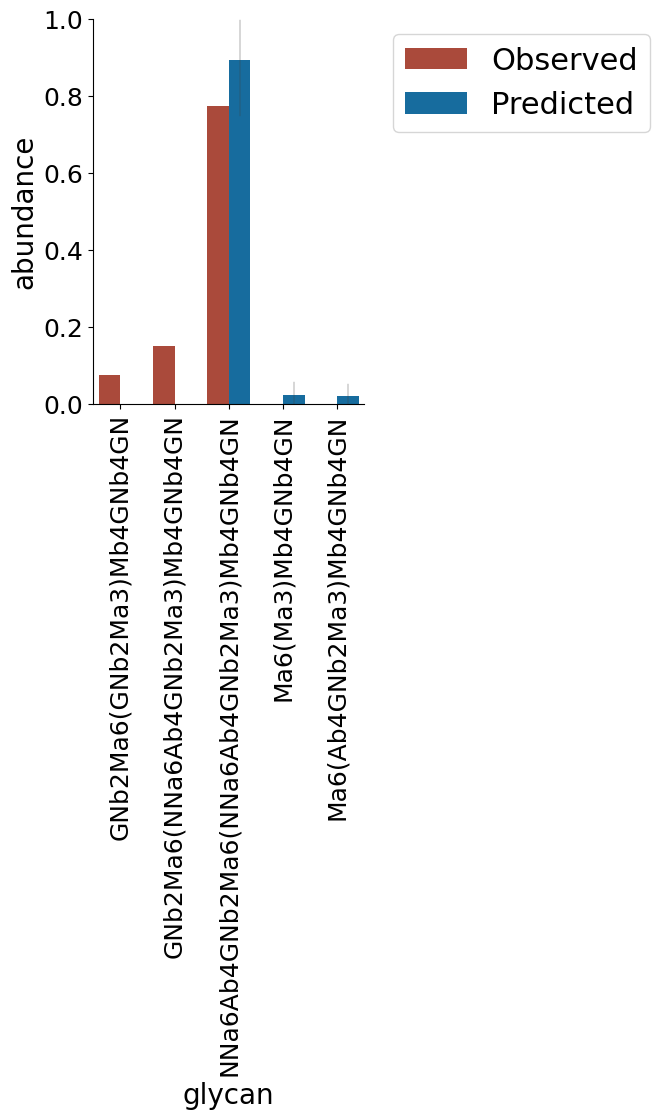

In [ ]:
#Plot the predicted glycoprofile vs measured glycoprofile for rhA1AT
rhA1AT_all_melt = myfun.melt_for_plot([best_pred_df.copy()], # , best_SIMpred_df.copy()
                                exp_gp.iloc[:,:2].copy(),
                                ['Predicted']) #,'predGP w/ simLP'
# fetb_all_melt.to_excel('../Data/'+YourFolder+'/SourceData/Prediction_FetB.xlsx',index = True)
myfun.plot_glycoprofile(rhA1AT_all_melt.copy(), threshold = plot_thres,
                        legend_loc='upper left',
                        color=['#BC3C29', '#0072B5', '#E18727'],
                        ylimit=1,
                        filename=YourFolder+'/Prediction_rhA1AT.1')
print("Plotted glycan names print out above")

['NNa6Ab4GNb2Ma6(NNa6Ab4GNb2Ma3)Mb4GNb4GN'
 'NNa6Ab4GNb2Ma6(NNa6Ab4GNb2Ma3)Mb4GNb4(Fa6)GN'
 'NNa6Ab4GNb4(NNa6Ab4GNb2)Ma6(NNa6Ab4GNb2Ma3)Mb4GNb4GN'
 'GNb2Ma6(GNb2Ma3)Mb4GNb4GN' 'GNb2Ma6(Ab4GNb2Ma3)Mb4GNb4GN'
 'Ma6(NNa3Ab4GNb2Ma3)Mb4GNb4GN']
        data standard_error
                       mean
0   Observed   8.792308e-18
1  Predicted   3.089733e-02


/Users/hainingli/Library/CloudStorage/GoogleDrive-kikiliof1998@gmail.com/My Drive/UCSD/PhD/Glyco-seq/2025Submission/Code/Functions.py:495: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  g = sns.barplot(data=test, x='glycan', y='abundance', hue='data', err_kws={'linewidth': 0.3}, palette=color)


Plotted glycan names print out above


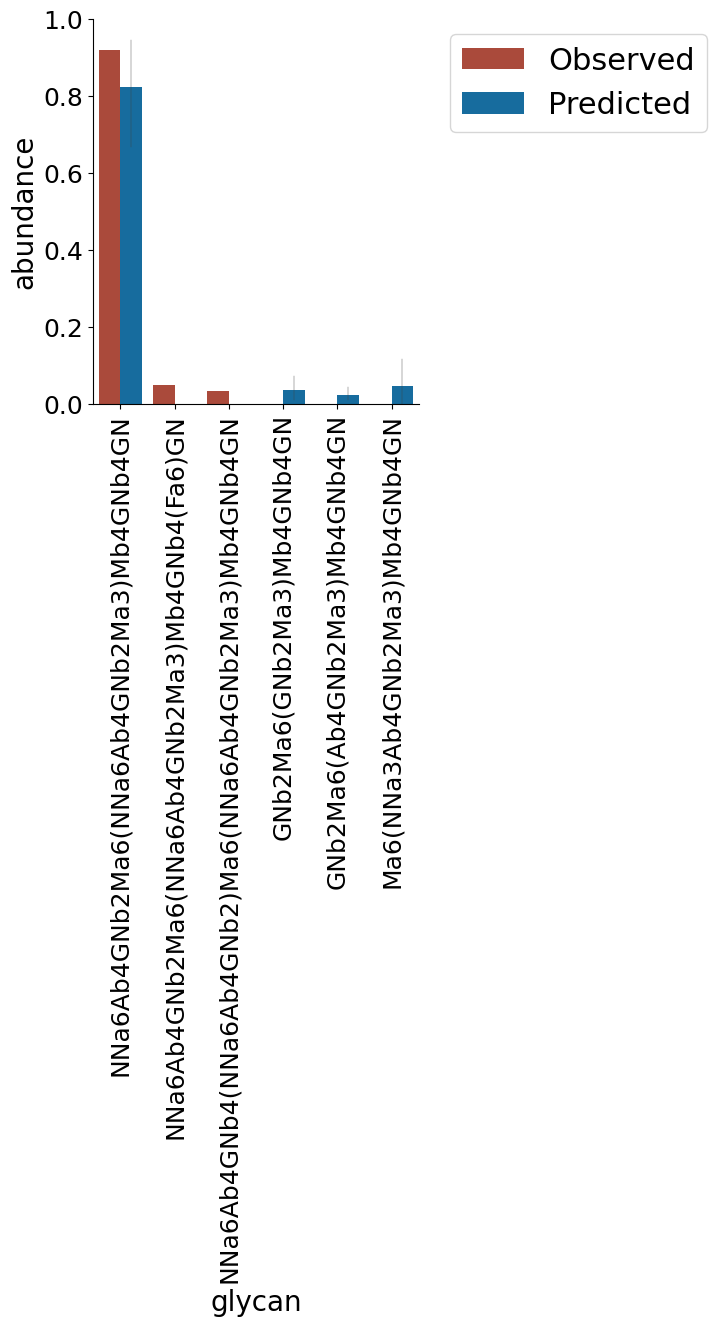

In [ ]:
#Plot the predicted glycoprofile vs measured glycoprofile for pdA1AT
pdA1AT_all_melt = myfun.melt_for_plot([best_pred_df.copy()], #, best_SIMpred_df.copy()
                                exp_gp.iloc[:,2:4].copy(),
                                ['Predicted']) #,'predGP w/ simLP'
# fetb_all_melt.to_excel('../Data/'+YourFolder+'/SourceData/Prediction_FetB.xlsx',index = True)
myfun.plot_glycoprofile(pdA1AT_all_melt.copy(), threshold = plot_thres,
                        legend_loc='upper left',
                        color=['#BC3C29', '#0072B5', '#E18727'],
                        ylimit=1,
                        filename=YourFolder+'/Prediction_pdA1AT.1')
print("Plotted glycan names print out above")

In [4]:
# Ready-to-run: multi-objective training and comparison
# Distinct YourLog names for each experiment
# Requires: train_lp, test_lp, train_gp, test_gp, (optional) test_SIMlp, and Functions.py updated

import pandas as pd
import numpy as np
import Functions as myfun

# Configure experiments
logs_cfg = [
    ("exp_baseline_mse", "baseline_mse", {}),
    ("exp_composite", "composite", {
        "presence_thresh": 0.02,
        "lambda_presence": 1.0,
        "lambda_abundance": 1.0,
        "lambda_masked": 0.5,
    }),
    ("exp_low_weighted_g2", "low_weighted", {
        "presence_thresh": 0.02,
        "lambda_presence": 1.0,
        "lambda_abundance": 1.0,
        "lambda_masked": 0.5,
        "low_abundance_gamma": 2.0,
    }),
]

# Run experiments (skip silently if log already exists)
for log_name, objective, extra in logs_cfg:
    _ = myfun.train_model_experiment(
        train_lp, test_lp, train_gp, test_gp,
        log_name=log_name,
        objective=objective,
        nrepeat=10,
        test_SIMlp=globals().get("test_SIMlp", None),
        record_all=False,
        ran_seed=8,
        **extra,
    )

# Load predictions and compute metrics
preds = []
labels = []
for log_name, _, _ in logs_cfg:
    rmse, pred_df_raw, exp_gp_raw, _ = myfun.load_result_npz(log_name, test_gp.copy(), record_all=False)
    # Ensure normalized and aligned
    pred_df = myfun.normalize(pred_df_raw.copy(), 0.01)
    exp_df = myfun.normalize(exp_gp_raw.copy(), 0.01)
    preds.append((pred_df, exp_df))
    labels.append(log_name)

# Per-glycan metrics summary
rows = []
for (pred, exp), name in zip(preds, labels):
    mae_g = myfun.mae_per_glycan(exp, pred)
    nrmse_g = myfun.nrmse_per_glycan(exp, pred, method="mean")
    rows.append({
        "experiment": name,
        "mean_MAE_per_glycan": float(mae_g.mean()),
        "mean_nRMSE_per_glycan": float(nrmse_g.mean()),
    })
metrics_summary_df = pd.DataFrame(rows)
print("Metrics summary (lower is better):")
display(metrics_summary_df.sort_values("mean_nRMSE_per_glycan").reset_index(drop=True))

# Visual comparison plot
pred_list = [p for p, _ in preds]
melt_df = myfun.melt_for_plot(pred_list, test_gp.copy(), name=labels)
_ = myfun.plot_glycoprofile(melt_df, threshold=0.05, filename="compare_experiments")


The LOG 'exp_baseline_mse' already exists. Stopping the execution to avoid overwrite.


2026-01-12 12:21:38.756778: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-01-12 12:21:38.756801: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-01-12 12:21:38.756806: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-01-12 12:21:38.756839: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-01-12 12:21:38.756858: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-01-12 12:21:39.294603: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
/Users/hainingli/miniforge3/env

/Users/hainingli/miniforge3/envs/new_TF/lib/python3.10/site-packages/keras/src/engine/training.py:2723: UserWarning: Metric AbundanceRMSE implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.
  m.reset_state()


/Users/hainingli/miniforge3/envs/new_TF/lib/python3.10/site-packages/keras/src/engine/training.py:2723: UserWarning: Metric AbundanceRMSE implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.
  m.reset_state()
/Users/hainingli/miniforge3/envs/new_TF/lib/python3.10/site-packages/keras/src/engine/training.py:2723: UserWarning: Metric AbundanceRMSE implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.
  m.reset_state()
/Users/hainingli/miniforge3/envs/new_TF/lib/python3.10/site-packages/keras/src/engine/training.py:2723: UserWarning: Metric AbundanceRMSE implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.
  m.reset_state()
/Users/hainingli/miniforge3/envs/n

KeyboardInterrupt: 

In [6]:
# Manual single-run training (smart objective via YourLog)
# Set your log name and hyperparameters, then run this cell.
# YourLog determines the objective automatically:
#   - "exp_baseline_mse" -> baseline single-head MSE
#   - "exp_composite" -> dual-head composite (presence+abundance)
#   - "exp_low_weighted_g2" -> dual-head with low-abundance weighting (gamma=2)

import pandas as pd
import numpy as np
import Functions as myfun

# ---- User inputs ----
YourLog = "exp_low_weighted_g2" #exp_baseline_mse,exp_composite,exp_low_weighted_g2  # change each time to avoid overwrite/objective
# shared training controls
epochs = 500                 # training epochs
batch_size = 4               # batch size
ran_seed = 8                 # set None for random

# model shape for baseline
size = 20                    # hidden units (baseline only)
depth = 4                    # number of hidden layers (baseline only)

# composite / low-weighted controls
presence_thresh = 0.02
lambda_presence = 1.0
lambda_abundance = 1.0
lambda_masked = 0.5
low_abundance_gamma = 2.0    # used when YourLog indicates low_weighted

# Optional: provide test_SIMlp if available in your session
_sim = globals().get("test_SIMlp", None)

# ---- Train a single run with smart objective ----
_ = myfun.train_model_smart(
    train_lp, test_lp, train_gp, test_gp,
    log_name=YourLog,
    epochs=epochs, batch_size=batch_size,
    ran_seed=ran_seed, test_SIMlp=_sim,
    size=size, depth=depth,
    presence_thresh=presence_thresh,
    lambda_presence=lambda_presence,
    lambda_abundance=lambda_abundance,
    lambda_masked=lambda_masked,
    low_abundance_gamma=low_abundance_gamma,
)

# # ---- Load results and compute metrics ----
# rmse_arr, pred_df_raw, exp_gp_raw, sim_pred_df_raw = myfun.load_result_npz(YourLog, test_gp.copy(), record_all=False)
# print("Test RMSE:", rmse_arr)

# # Normalize and align
# pred_df = myfun.normalize(pred_df_raw.copy(), 0.01)
# exp_df = myfun.normalize(exp_gp_raw.copy(), 0.01)

# # Per-glycan metrics
# mae_g = myfun.mae_per_glycan(exp_df, pred_df)
# nrmse_g = myfun.nrmse_per_glycan(exp_df, pred_df, method="mean")
# print("Mean per-glycan MAE:", float(mae_g.mean()))
# print("Mean per-glycan nRMSE:", float(nrmse_g.mean()))

# # Visualize prediction vs observed (bar plot)
# melt_df = myfun.melt_for_plot([pred_df.copy()], test_gp.copy(), name=[YourLog])
# _ = myfun.plot_glycoprofile(melt_df, threshold=0.05, filename=f"{YourLog}_plot")


/Users/hainingli/miniforge3/envs/new_TF/lib/python3.10/site-packages/keras/src/engine/training.py:2723: UserWarning: Metric AbundanceRMSE implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.
  m.reset_state()


['Ma6(GNb2Ma3)Mb4GNb4GN' 'GNb2Ma6(GNb2Ma3)Mb4GNb4GN'
 'GNb2Ma6(NNa6Ab4GNb2Ma3)Mb4GNb4GN'
 'NNa6Ab4GNb2Ma6(NNa6Ab4GNb2Ma3)Mb4GNb4GN'
 'Ab4GNb2Ma6(NNa3Ab4GNb2Ma3)Mb4GNb4(Fa6)GN'
 'Ab4GNb2Ma6(Ab4GNb4(Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN']
             data standard_error
                            mean
0    Baseline_MSE            0.0
1       Composite            0.0
2  LowWeighted_g2            0.0
3        Observed            0.0


/Users/hainingli/Library/CloudStorage/GoogleDrive-kikiliof1998@gmail.com/My Drive/UCSD/PhD/Glyco-seq/2025Submission/Code/Functions.py:495: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  g = sns.barplot(data=test, x='glycan', y='abundance', hue='data', err_kws={'linewidth': 0.3}, palette=color)


['NNa6Ab4GNb2Ma6(NNa6Ab4GNb2Ma3)Mb4GNb4GN'
 'NNa6Ab4GNb2Ma6(NNa6Ab4GNb2Ma3)Mb4GNb4(Fa6)GN'
 'NNa6Ab4GNb4(NNa6Ab4GNb2)Ma6(NNa6Ab4GNb2Ma3)Mb4GNb4GN'
 'NNa6Ab4GNb2Ma6(NNa6Ab4GNb4(NNa6Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN'
 'NNa3Ab4GNb2Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN'
 'Ma6(Ma2Ma3)Mb4GNb4GN']
             data standard_error
                            mean
0    Baseline_MSE            0.0
1       Composite            0.0
2  LowWeighted_g2            0.0
3        Observed            0.0


/Users/hainingli/Library/CloudStorage/GoogleDrive-kikiliof1998@gmail.com/My Drive/UCSD/PhD/Glyco-seq/2025Submission/Code/Functions.py:495: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  g = sns.barplot(data=test, x='glycan', y='abundance', hue='data', err_kws={'linewidth': 0.3}, palette=color)


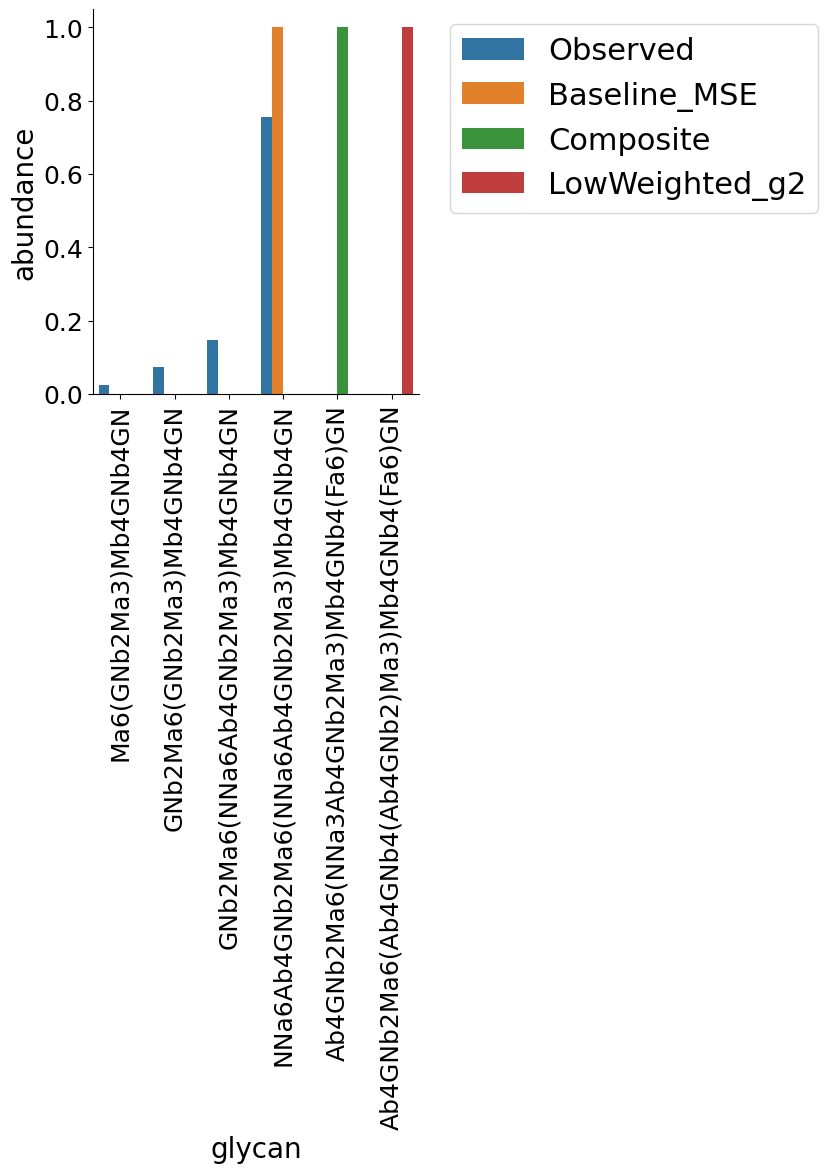

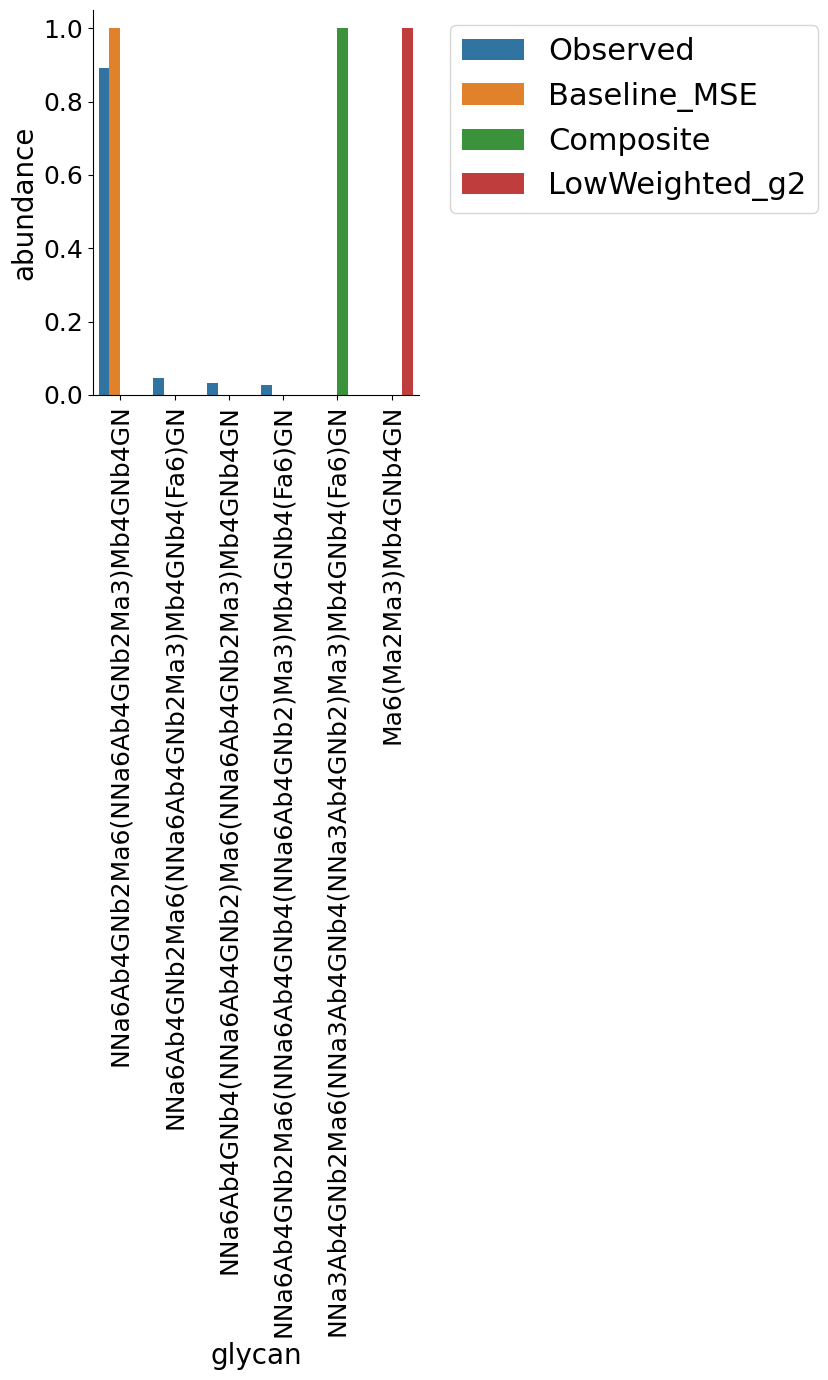

In [19]:
# Compare predictions from three logs against observed test_gp
# Two bar plots: first 3 columns and last 3 columns of predictions

import pandas as pd
import numpy as np
import Functions as myfun

logs = [
    # "A1AT_log1",
    "exp_baseline_mse",
    "exp_composite",
    "exp_low_weighted_g2",
]
labels = [
    # "RMSE",
    "Baseline_MSE",
    "Composite",
    "LowWeighted_g2",
]

pred_list = []
exp_df_final = None

for lg in logs:
    rmse, pred_df_raw, exp_gp_raw, _ = myfun.load_result_npz(lg, test_gp.copy(), record_all=False)
    # Normalize observed to be consistent
    exp_df = myfun.normalize(exp_gp_raw.copy(), 0.02)
    pred_df = pred_df_raw.copy()  # already normalized in load_result_npz
    exp_df_final = exp_df  # same alignment for all logs
    pred_list.append(pred_df)

# Determine column groups (first 3 and last 3)
all_cols = list(exp_df_final.columns)
cols_first3 = all_cols[:2]
cols_last3 = all_cols[2:4]

# Subset predictions and observed
pred_first = [p.loc[:, cols_first3] for p in pred_list]
exp_first = exp_df_final.loc[:, cols_first3]

pred_last = [p.loc[:, cols_last3] for p in pred_list]
exp_last = exp_df_final.loc[:, cols_last3]

# Plot first 3 columns
melt_first = myfun.melt_for_plot(pred_first, exp_first.copy(), name=labels)
_ = myfun.plot_glycoprofile(melt_first, threshold=0.01, filename="compare_first3")

# Plot last 3 columns
melt_last = myfun.melt_for_plot(pred_last, exp_last.copy(), name=labels)
_ = myfun.plot_glycoprofile(melt_last, threshold=0.01, filename="compare_last3")


In [16]:
exp_gp_raw.sum()


rhA1AT.1    1.0
rhA1AT.2    1.0
pdA1AT.1    1.0
pdA1AT.2    1.0
FetB.1      1.0
FetB.2      1.0
dtype: float64

In [8]:
pred_df

,rhA1AT.1,rhA1AT.2,pdA1AT.1,pdA1AT.2,FetB.1,FetB.2
Ma6(Ma3)Mb4GNb4GN,0.0,0.0,0.0,0.0,0.0,0.0
Ma6(Ma2Ma3)Mb4GNb4GN,0.0,0.0,0.0,0.0,0.0,0.0
Ma6(GNb2Ma3)Mb4GNb4GN,0.0,0.0,0.0,0.0,0.0,0.0
Ma6(Ma3)Mb4GNb4(Fa6)GN,0.0,0.0,0.0,0.0,0.0,0.0
Ma6(Ab4GNb2Ma3)Mb4GNb4GN,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...
Ab4GNb3Ab4GNb6(NNa3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN,0.0,0.0,0.0,0.0,0.012389,0.0
NNa3Ab4GNb3Ab4GNb6(NNa3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN,0.0,0.0,0.0,0.0,0.0,0.0
NNa3Ab4GNb3Ab4GNb3Ab4GNb6(NNa3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4GN,0.0,0.0,0.0,0.0,0.0,0.0
NNa3Ab4GNb3Ab4GNb6(Ab4GNb3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN,0.0,0.0,0.0,0.0,0.0,0.0
